# 데이터 로드

In [1]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 설정
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 기본 설정
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ 라이브러리 Import 완료!")

✅ 라이브러리 Import 완료!


In [2]:
# 데이터 로드
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"데이터 크기: {df.shape}")
print(f"컬럼 수: {df.shape[1]}")
print(f"행 수 : {df.shape[0]:,}")

데이터 크기: (7043, 21)
컬럼 수: 21
행 수 : 7,043


In [19]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

- customerID : 소비자의 식별자
- gender : 성별
- SeniorCitizen : 노인인지의 여부
- Partner : 배우자의 유무
- Dependents : 자녀의 유무
- tenure : 고객의 가입 기간 (개월 수)
- PhoneService : 휴대폰 서비스를 가입 했는지의 여부
- MultipleLines : 여러 개의 통신선을 서비스 받고 있는지의 여부 (Yes, No, No phone service) / 휴대폰 서비스를 가입한 고객만 해당됨.
- InternetService : 인터넷 서비스 제공자 (DSL, Fiber optic, No)
- OnlineSecurity : 온라인 보안 서비스를 가입 했는지의 여부 (Yes, No, No internet service) / 인터넷 서비스를 가입한 고객만 해당됨.
- OnlineBackup : 온라인 백업 서비스를 가입 했는지의 여부 (Yes, No, No internet service) / 인터넷 서비스를 가입한 고객만 해당됨.
- DeviceProtection 기기 보호 서비스를 가입 했는지의 여부 (Yes, No, No internet service) / 인터넷 서비스를 가입한 고객만 해당됨.
- TechSupport : 기술 서포트 서비스를 가입 했는지의 여부 (Yes, No, No internet service) / 인터넷 서비스를 가입한 고객만 해당됨.
- StreamingTV : TV 스트리밍 서비스를 가입 했는지의 여부 (Yes, No, No internet service) / 인터넷 서비스를 가입한 고객만 해당됨.
- StreamingMovies : 영화 스트리밍 서비스를 가입 했는지의 여부 (Yes, No, No internet service) / 인터넷 서비스를 가입한 고객만 해당됨.
- Contract : 계약 유형 (Month-to-month, One year, Two year)
- PaperlessBilling : 전자 고지서 여부
- PaymentMethod : 요금 지불 방법 (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- MonthlyCharges : 매달 고객에게 청구되는 금액
- TotalCharges : 고객에게 청구된 총 금액
- Churn : 지난 한 달 내에 떠난 고객인지의 여부 [target]

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


- TotalCharges는 수치형변수로 변경 필요

In [22]:
df['TotalCharges']

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [ ]:
# TotalCharges 컬럼이 숫자형이 아닌 문자열로 되어 있어, 숫자로 변환하면서 오류가 발생하는 경우가 있음 → 'coerce' 옵션으로 변환 실패 시 NaN 처리
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [24]:
df.info()
# 범주형 변수 : 17
# 수치형 변수 : 4

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [28]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Target 변수 분석(이탈률)

🎯 Target 변수 분석: Churn (이탈 여부)

이탈 고객 수: 1,869명 (26.54%)
유지 고객 수: 5,174명 (73.46%)


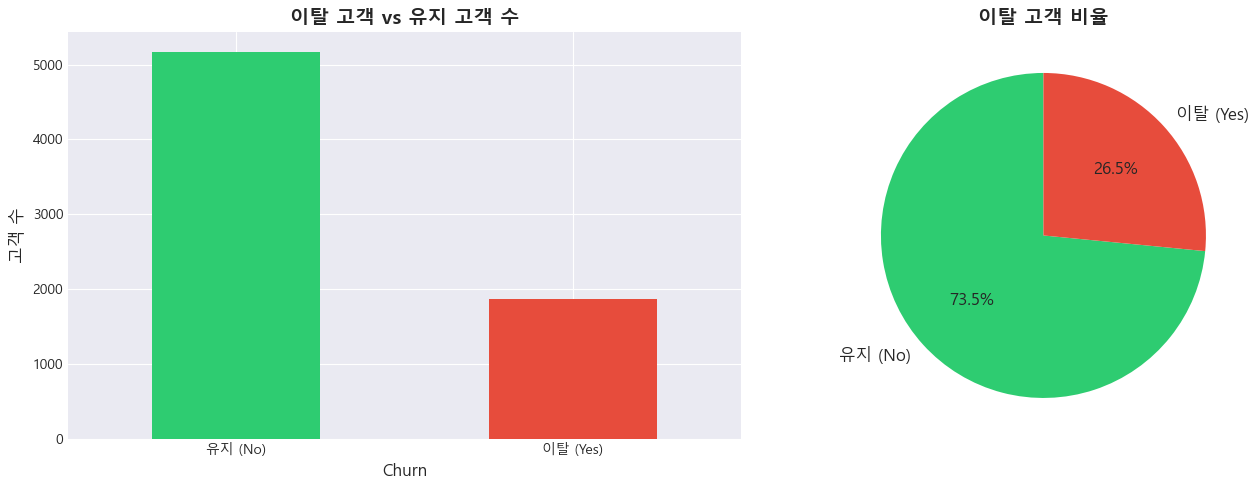

In [13]:
# 이탈률 계산
print("="*60)
print("🎯 Target 변수 분석: Churn (이탈 여부)")
print("="*60)

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"\n이탈 고객 수: {churn_counts['Yes']:,}명 ({churn_pct['Yes']:.2f}%)")
print(f"유지 고객 수: {churn_counts['No']:,}명 ({churn_pct['No']:.2f}%)")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('이탈 고객 vs 유지 고객 수', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('고객 수', fontsize=12)
axes[0].set_xticklabels(['유지 (No)', '이탈 (Yes)'], rotation=0)

# 파이 차트
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(churn_counts, labels=['유지 (No)', '이탈 (Yes)'], autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 12})
axes[1].set_title('이탈 고객 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


💡 인사이트: 약 26-27%의 고객이 이탈 → 불균형 데이터 (SMOTE 필요)

## 수치형 변수 분포 분석

In [25]:
# 수치형 변수 확인
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("수치형 변수:", numeric_cols)

수치형 변수: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [26]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
# 결측값은 TotalCharges 컬럼에만 존재하며, 11개로 전체 데이터의 약 0.15%에 해당 → 제거해도 무방할 것으로 판단
missing_df = df[df.isnull()]
missing_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


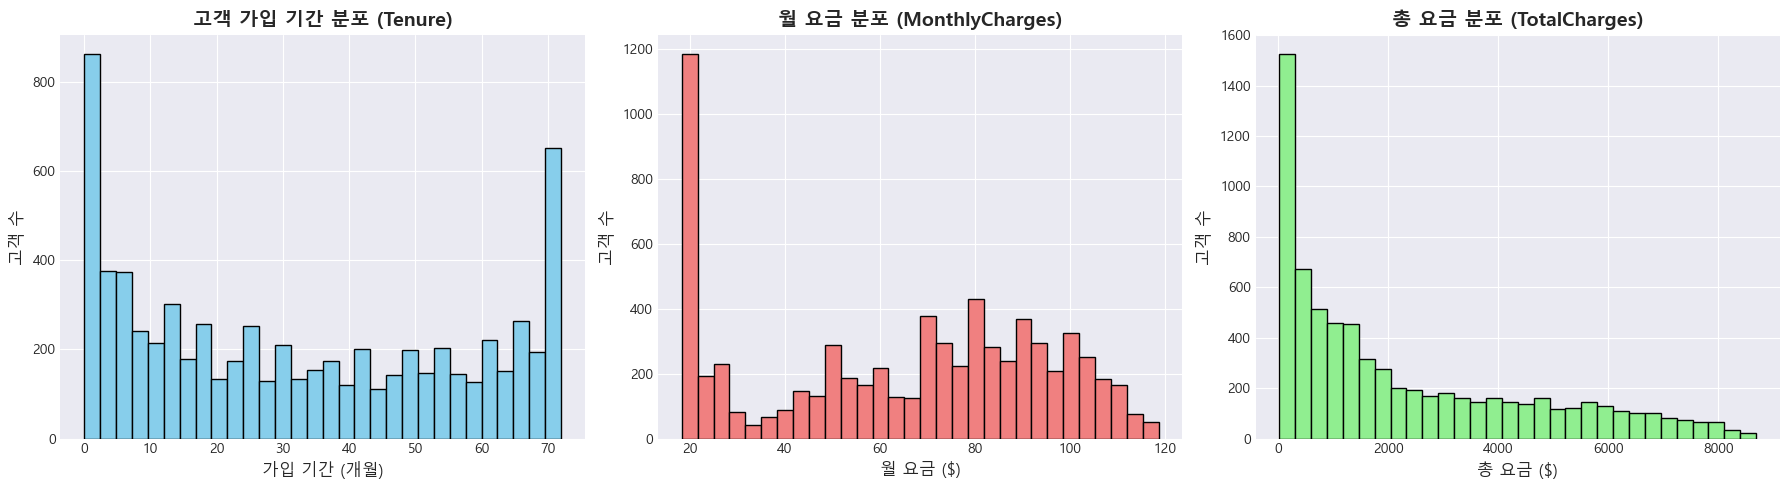

In [34]:
# tenure, MonthlyCharges, TotalCharges 분포
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# tenure (재직 기간)
axes[0].hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('고객 가입 기간 분포 (Tenure)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('가입 기간 (개월)', fontsize=12)
axes[0].set_ylabel('고객 수', fontsize=12)

# MonthlyCharges (월 요금)
axes[1].hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black')
axes[1].set_title('월 요금 분포 (MonthlyCharges)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('월 요금 ($)', fontsize=12)
axes[1].set_ylabel('고객 수', fontsize=12)

# TotalCharges (총 요금) - 공백 제거 후 숫자 변환
axes[2].hist(df['TotalCharges'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[2].set_title('총 요금 분포 (TotalCharges)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('총 요금 ($)', fontsize=12)
axes[2].set_ylabel('고객 수', fontsize=12)

plt.tight_layout()
plt.show()

## 범주형 변수와 이탈률 관계

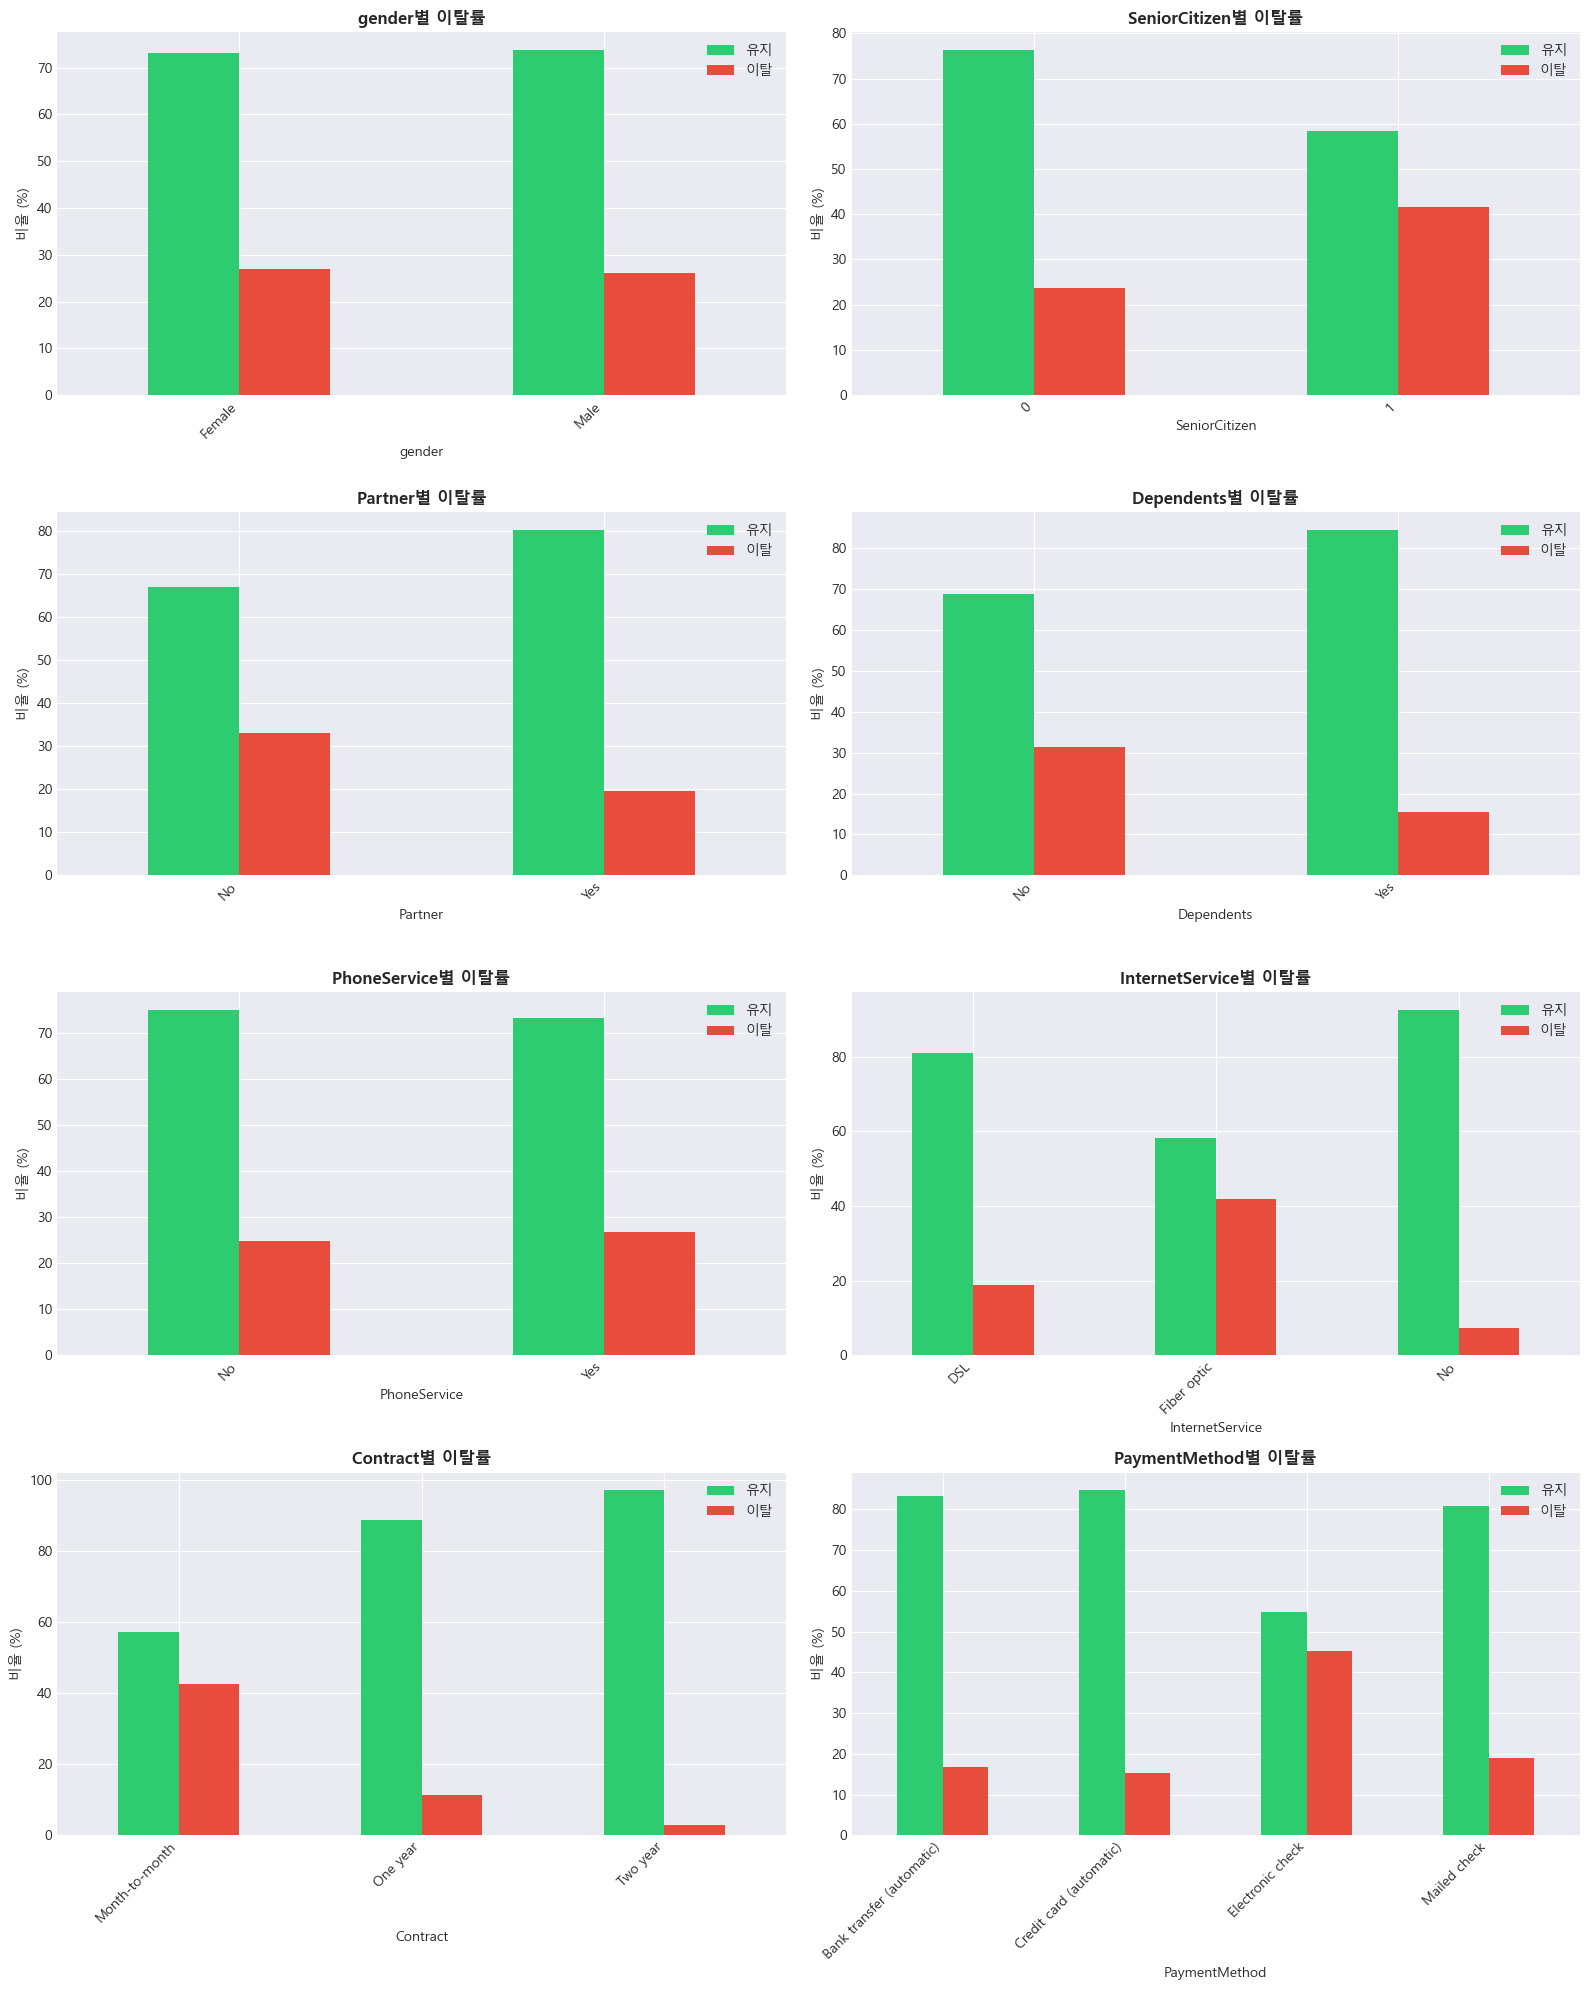

In [35]:
# 주요 범주형 변수
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                    'PhoneService', 'InternetService', 'Contract', 'PaymentMethod']

# 4x2 그리드로 시각화
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    # 이탈률 계산
    churn_by_category = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    
    # 막대 그래프
    churn_by_category.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col}별 이탈률', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('비율 (%)', fontsize=10)
    axes[idx].legend(['유지', '이탈'], loc='upper right')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 계약 유형별 이탈률

📋 계약 유형 (Contract)별 이탈률
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


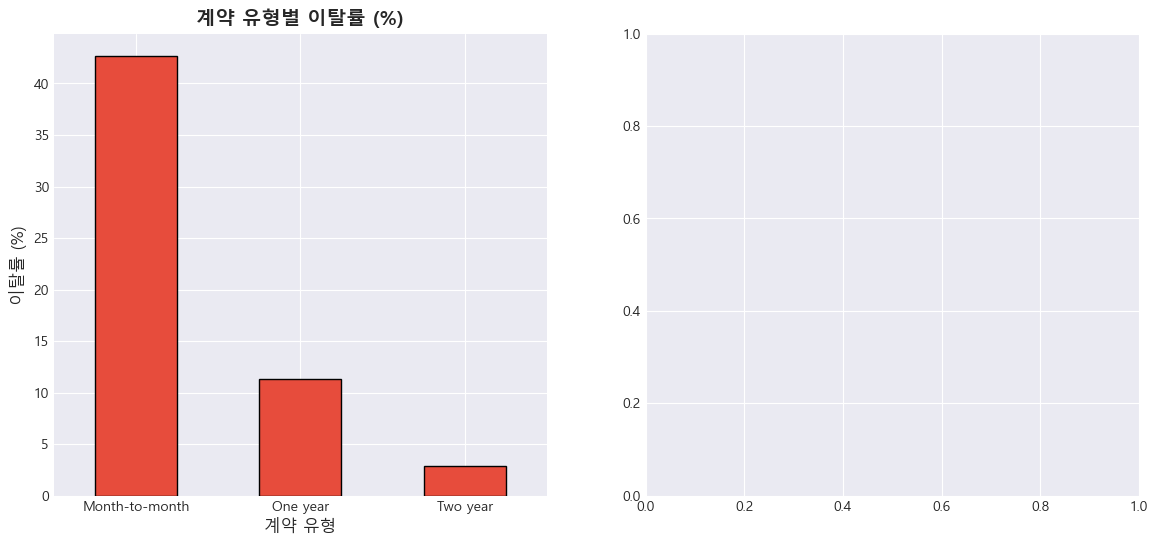

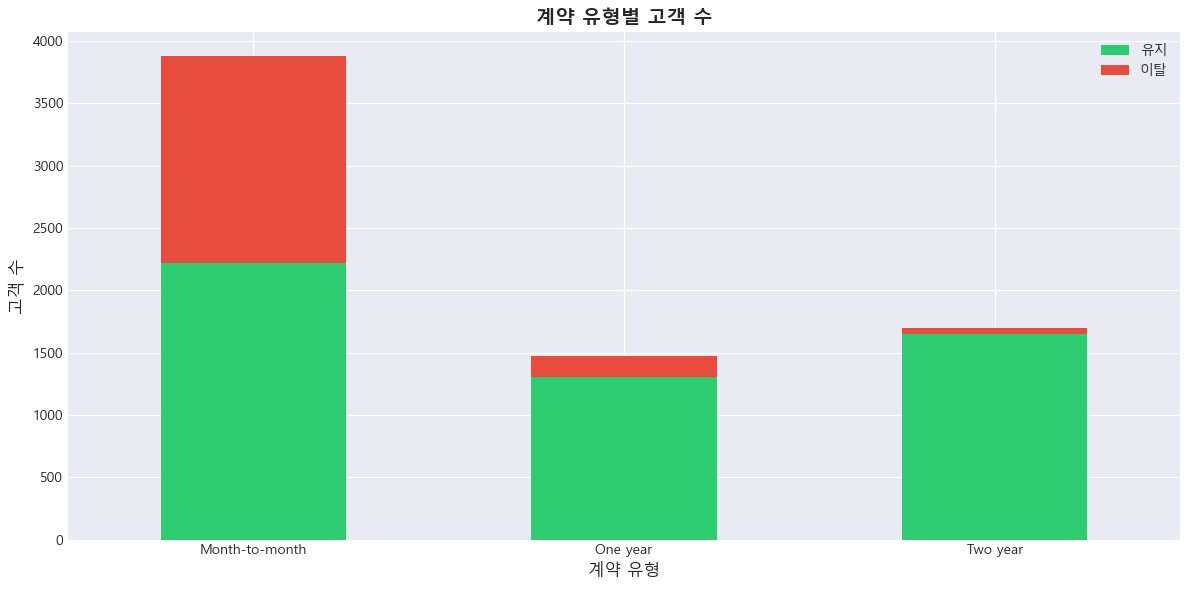

In [39]:
# 계약 유형별 상세 분석
print("="*60)
print("📋 계약 유형 (Contract)별 이탈률")
print("="*60)

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn)

# 시각화
fig = plt.figure(figsize=(14, 6))

# 막대 그래프
plt.subplot(1, 2, 1)
contract_churn['Yes'].plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('계약 유형별 이탈률 (%)', fontsize=14, fontweight='bold')
plt.xlabel('계약 유형', fontsize=12)
plt.ylabel('이탈률 (%)', fontsize=12)
plt.xticks(rotation=0)

# 고객 수와 함께 표시
plt.subplot(1, 2, 2)
contract_counts = df.groupby(['Contract', 'Churn']).size().unstack()
contract_counts.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'])
plt.title('계약 유형별 고객 수', fontsize=14, fontweight='bold')
plt.xlabel('계약 유형', fontsize=12)
plt.ylabel('고객 수', fontsize=12)
plt.legend(['유지', '이탈'], loc='upper right')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

💡 인사이트:
- Month-to-month 계약: 이탈률 가장 높음 (~42%)
- One year, Two year 계약: 이탈률 낮음 (~11-15%)
→ 장기 계약 유도 전략 필요!

## 인터넷 서비스별 이탈률

🌐 인터넷 서비스별 이탈률
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


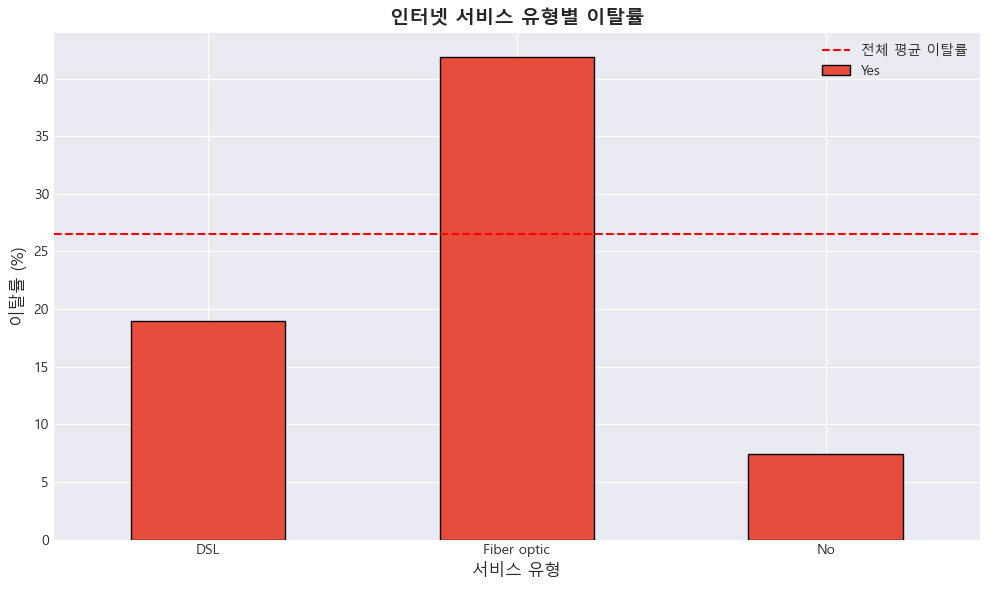

In [41]:
# 인터넷 서비스 유형별 분석
print("="*60)
print("🌐 인터넷 서비스별 이탈률")
print("="*60)

internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(internet_churn)

# 시각화
plt.figure(figsize=(10, 6))
internet_churn['Yes'].plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('인터넷 서비스 유형별 이탈률', fontsize=14, fontweight='bold')
plt.xlabel('서비스 유형', fontsize=12)
plt.ylabel('이탈률 (%)', fontsize=12)
plt.xticks(rotation=0)
plt.axhline(y=df['Churn'].value_counts(normalize=True)['Yes']*100, 
            color='red', linestyle='--', label='전체 평균 이탈률')
plt.legend()
plt.tight_layout()
plt.show()


💡 핵심 인사이트:
- Fiber optic: 이탈률 가장 높음 (~42%)
- DSL: 중간 수준 (~19%)
- No internet service: 가장 낮음 (~7%)

## 월 요금과 이탈 관계

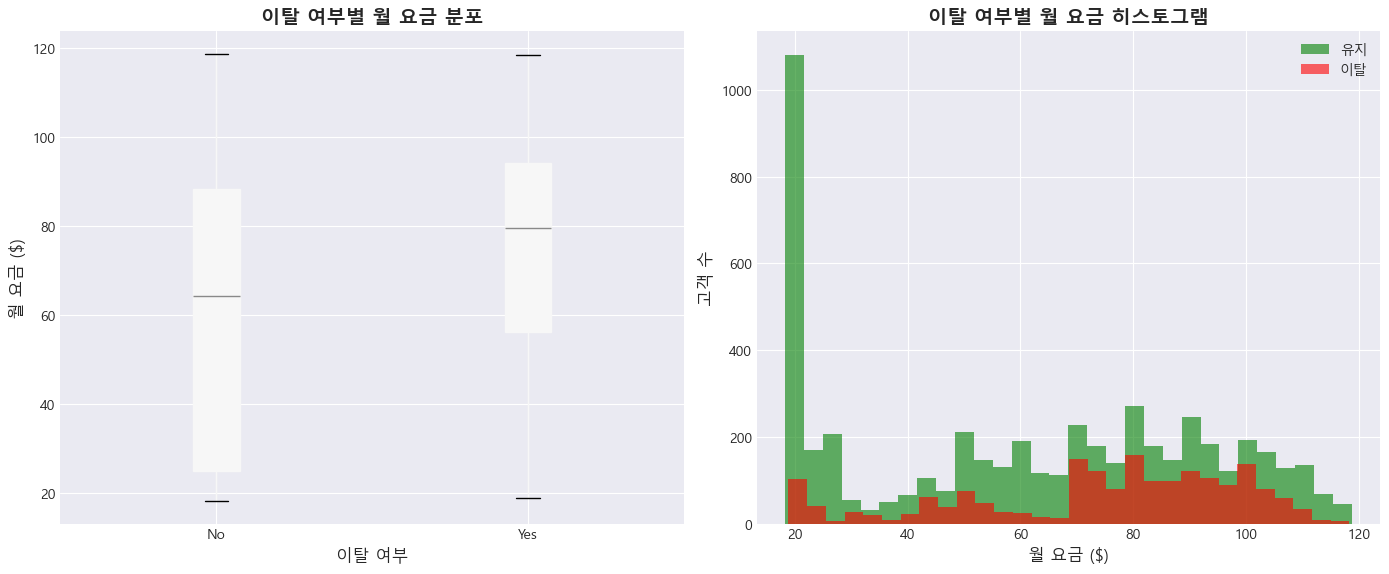

💰 월 요금 통계
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [43]:
# 월 요금과 이탈률의 관계
plt.figure(figsize=(14, 6))

# Boxplot
plt.subplot(1, 2, 1)
df.boxplot(column='MonthlyCharges', by='Churn', ax=plt.gca(), patch_artist=True)
plt.title('이탈 여부별 월 요금 분포', fontsize=14, fontweight='bold')
plt.xlabel('이탈 여부', fontsize=12)
plt.ylabel('월 요금 ($)', fontsize=12)
plt.suptitle('')

# Histogram
plt.subplot(1, 2, 2)
df[df['Churn'] == 'No']['MonthlyCharges'].hist(bins=30, alpha=0.6, label='유지', color='green')
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(bins=30, alpha=0.6, label='이탈', color='red')
plt.title('이탈 여부별 월 요금 히스토그램', fontsize=14, fontweight='bold')
plt.xlabel('월 요금 ($)', fontsize=12)
plt.ylabel('고객 수', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# 평균 비교
print("="*60)
print("💰 월 요금 통계")
print("="*60)
print(df.groupby('Churn')['MonthlyCharges'].describe())



💡 인사이트: 이탈 고객의 평균 월 요금이 더 높음!

## 재직 기간과 이탈 관계

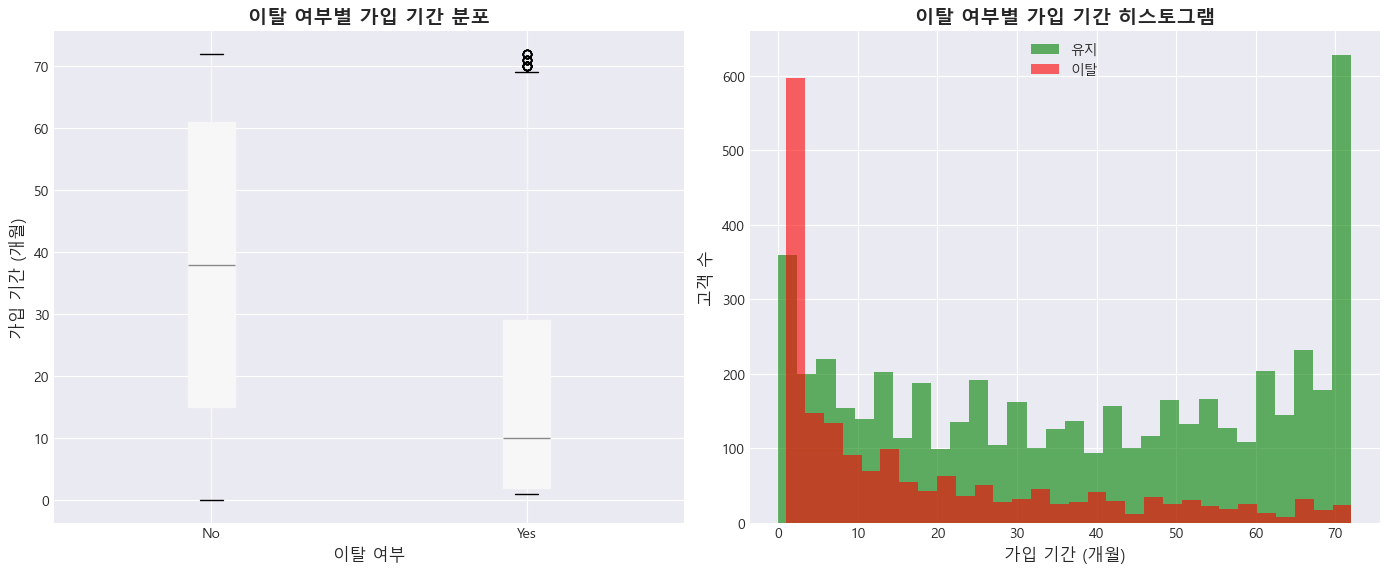

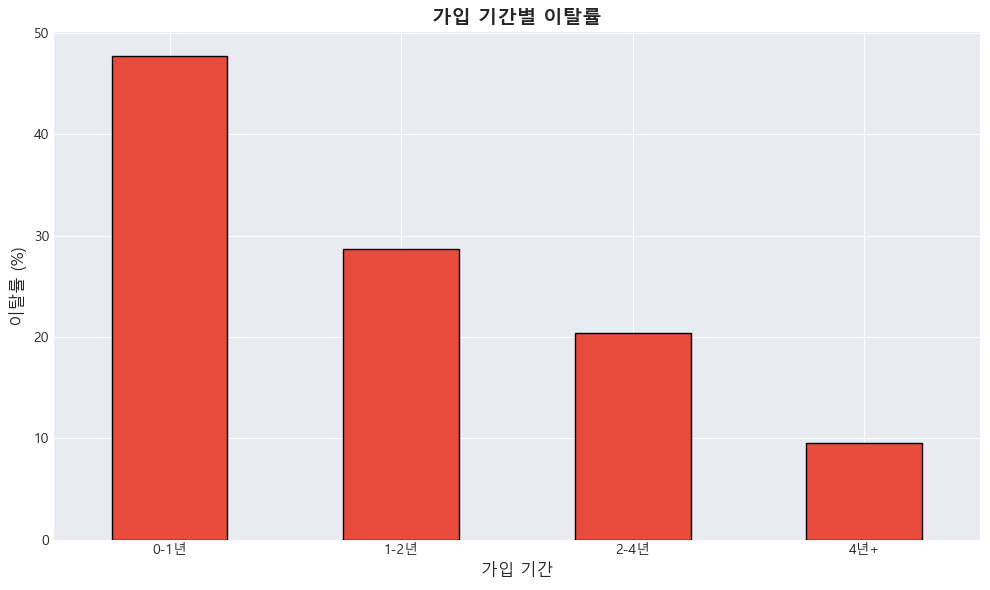

In [46]:
# Tenure (가입 기간)과 이탈의 관계
plt.figure(figsize=(14, 6))

# Boxplot
plt.subplot(1, 2, 1)
df.boxplot(column='tenure', by='Churn', ax=plt.gca(), patch_artist=True)
plt.title('이탈 여부별 가입 기간 분포', fontsize=14, fontweight='bold')
plt.xlabel('이탈 여부', fontsize=12)
plt.ylabel('가입 기간 (개월)', fontsize=12)
plt.suptitle('')

# Histogram
plt.subplot(1, 2, 2)
df[df['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.6, label='유지', color='green')
df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.6, label='이탈', color='red')
plt.title('이탈 여부별 가입 기간 히스토그램', fontsize=14, fontweight='bold')
plt.xlabel('가입 기간 (개월)', fontsize=12)
plt.ylabel('고객 수', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# 가입 기간 구간별 이탈률
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], 
                             labels=['0-1년', '1-2년', '2-4년', '4년+'])

tenure_churn = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(10, 6))
tenure_churn['Yes'].plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('가입 기간별 이탈률', fontsize=14, fontweight='bold')
plt.xlabel('가입 기간', fontsize=12)
plt.ylabel('이탈률 (%)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


💡 핵심 인사이트:
- 가입 기간이 짧을수록 이탈률 높음 (0-1년: ~50%)
- 가입 기간이 길수록 이탈률 낮음 (4년+: ~15%)
→ 초기 6-12개월이 이탈 방지의 핵심 기간!

## 상관관계 분석

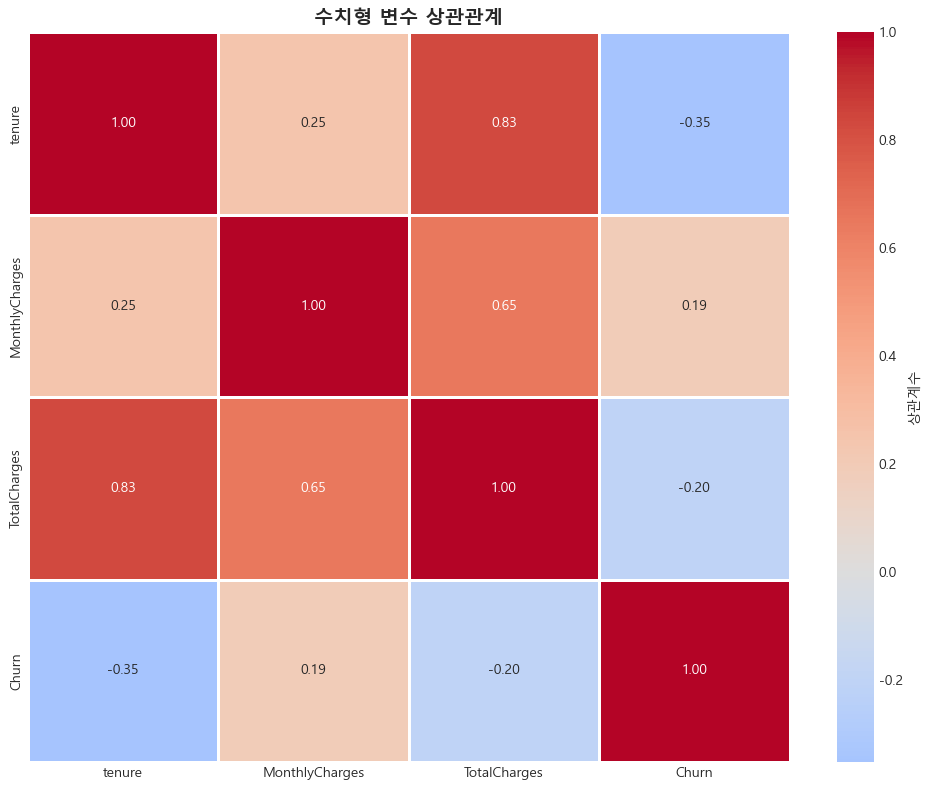

In [48]:
# 수치형 변수 간 상관관계
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=1, cbar_kws={'label': '상관계수'})
plt.title('수치형 변수 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


💡 발견사항:
- tenure와 TotalCharges는 강한 양의 상관관계 (0.83)
- MonthlyCharges와 Churn은 약한 양의 상관관계
- tenure와 Churn은 음의 상관관계 (재직 기간 ↑ → 이탈률 ↓)

In [49]:
print("="*60)
print("📊 EDA 주요 인사이트 요약")
print("="*60)

insights = """
1️⃣ 이탈률: 전체 고객의 약 26-27%가 이탈
   → 불균형 데이터 → SMOTE 적용 필요

2️⃣ 계약 유형의 영향력 큰 편:
   - Month-to-month: 이탈률 42% (가장 높음)
   - One year: 11%
   - Two year: 3% (가장 낮음)
   → 장기 계약 전환 프로모션 필요

3️⃣ 인터넷 서비스:
   - Fiber optic 사용자의 이탈률이 DSL 대비 2배 이상
   → Fiber optic 서비스 품질 개선 필요

4️⃣ 재직 기간(Tenure):
   - 0-1년 고객의 이탈률 50% (매우 높음)
   - 4년 이상 고객의 이탈률 15%
   → 초기 고객 유지 전략 강화 (온보딩, 프로모션)

5️⃣ 월 요금:
   - 이탈 고객의 평균 월 요금이 더 높음
   → 가격 민감도 높은 고객층 존재

6️⃣ Feature Engineering 아이디어:
   - tenure_group: 재직 기간 구간화
   - avg_monthly_charges: TotalCharges / tenure
   - total_services: 이용 중인 서비스 개수
"""

print(insights)

print("\n" + "="*60)
print("✅ EDA 완료! 다음 단계: Feature Engineering & Modeling")
print("="*60)

📊 EDA 주요 인사이트 요약

1️⃣ 이탈률: 전체 고객의 약 26-27%가 이탈
   → 불균형 데이터 → SMOTE 적용 필요

2️⃣ 계약 유형의 영향력 큰 편:
   - Month-to-month: 이탈률 42% (가장 높음)
   - One year: 11%
   - Two year: 3% (가장 낮음)
   → 장기 계약 전환 프로모션 필요

3️⃣ 인터넷 서비스:
   - Fiber optic 사용자의 이탈률이 DSL 대비 2배 이상
   → Fiber optic 서비스 품질 개선 필요

4️⃣ 재직 기간(Tenure):
   - 0-1년 고객의 이탈률 50% (매우 높음)
   - 4년 이상 고객의 이탈률 15%
   → 초기 고객 유지 전략 강화 (온보딩, 프로모션)

5️⃣ 월 요금:
   - 이탈 고객의 평균 월 요금이 더 높음
   → 가격 민감도 높은 고객층 존재

6️⃣ Feature Engineering 아이디어:
   - tenure_group: 재직 기간 구간화
   - avg_monthly_charges: TotalCharges / tenure
   - total_services: 이용 중인 서비스 개수


✅ EDA 완료! 다음 단계: Feature Engineering & Modeling


In [60]:
print("="*60)
print("💾 정제된 데이터 저장 준비")
print("="*60)

# 1. TotalCharges 타입 확인
print(f"\n1️⃣ TotalCharges 현재 타입: {df['TotalCharges'].dtype}")

# 2. TotalCharges 결측치 확인 및 처리
missing_count = df['TotalCharges'].isna().sum()
print(f"\n2️⃣ TotalCharges 결측치: {missing_count}개")

if missing_count > 0:
    median_value = df['TotalCharges'].median()
    print(f"   중앙값: {median_value:.2f}")
    df['TotalCharges'].fillna(median_value, inplace=True)
    print(f"   ✅ 결측치 대체 완료")

# 3. EDA에서 생성한 임시 컬럼 제거 (Feature Engineering에서 다시 생성)
temp_cols_to_drop = ['tenure_group']  # EDA 중 생성된 임시 컬럼
existing_temp_cols = [col for col in temp_cols_to_drop if col in df.columns]

if existing_temp_cols:
    print(f"\n3️⃣ 임시 컬럼 제거: {existing_temp_cols}")
    df.drop(existing_temp_cols, axis=1, inplace=True)
    print("   ✅ 제거 완료 (Feature Engineering에서 재생성 예정)")

# 4. 전체 데이터 결측치 최종 확인
print(f"\n4️⃣ 전체 데이터 결측치 확인:")
total_missing = df.isnull().sum()
if total_missing.sum() > 0:
    print("⚠️  남아있는 결측치:")
    print(total_missing[total_missing > 0])
else:
    print("✅ 모든 결측치 처리 완료!")

# 5. 데이터 저장
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/churn_data_eda.csv', index=False)

print("\n" + "="*60)
print("✅ 정제된 데이터 저장 완료!")
print(f"   경로: data/processed/churn_data_eda.csv")
print(f"   크기: {df.shape}")
print(f"   컬럼 수: {df.shape[1]}")
print(f"   결측치: {df.isnull().sum().sum()}개")
print("="*60)

💾 정제된 데이터 저장 준비

1️⃣ TotalCharges 현재 타입: float64

2️⃣ TotalCharges 결측치: 0개

3️⃣ 임시 컬럼 제거: ['tenure_group']
   ✅ 제거 완료 (Feature Engineering에서 재생성 예정)

4️⃣ 전체 데이터 결측치 확인:
✅ 모든 결측치 처리 완료!

✅ 정제된 데이터 저장 완료!
   경로: data/processed/churn_data_eda.csv
   크기: (7043, 21)
   컬럼 수: 21
   결측치: 0개
